In [221]:
import numpy as np
import matplotlib.pyplot as plt

In [222]:
x0=2.8
v0=0
m=1
T=100
dx=1e-3
b = [0.5, 5]

In [223]:
def phi(x, l1=1, l2=1/np.sqrt(8)):
    return -np.exp(-x**2/l1**2)-8*np.exp(-(x-2)**2/l2**2)

In [224]:
def dphi_dx(x, dx=1e-3):
    return (phi(x + dx) - phi(x - dx)) / (2.0*dx)

In [225]:
def d2phi_dx2(x, dx=1e-3):
    return (phi(x + dx) - 2.0*phi(x) + phi(x - dx)) / (dx**2)

In [226]:
def accelaration(x, v, mass=m, b=0):
    return -1/mass * dphi_dx(x) -b*v

In [227]:
def da_dx(x, mass=1.0):
    return - (1.0/mass)*d2phi_dx2(x)

In [228]:
def da_dv(b=0.0):
    return -b

In [229]:
def energy(x, v, mass=m):
    return 0.5*mass*v**2+phi(x)

In [230]:
def rk4(xn, vn, dt, mass=m, b=0):
    def f(x, v):
        a = accelaration(x, v, mass, b)
        return np.array([v, a])
    
    k1 = f(xn, vn)
    k2 = f(xn + 0.5*dt*k1[0], vn + 0.5*dt*k1[1])
    k3 = f(xn + 0.5*dt*k2[0], vn + 0.5*dt*k2[1])
    k4 = f(xn + dt*k3[0], vn + dt*k3[1])
    
    x_new = xn + (dt/6.0)*(k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
    v_new = vn + (dt/6.0)*(k1[1] + 2*k2[1] + 2*k3[1] + k4[1])
    return x_new, v_new


In [231]:
def trapezoid(xn, vn, dt, mass=1.0, b=0, max_iter=50, tol_iter=1e-12):
    
    an = accelaration(xn, vn, mass, b)  

    x_guess, v_guess = xn, vn

    for _ in range(max_iter):
        a_guess = accelaration(x_guess, v_guess, mass, b)

        F1 = x_guess - xn - 0.5*dt*(v_guess + vn)
        F2 = v_guess - vn - 0.5*dt*(a_guess + an)

        dF1_dx = 1.0
        dF1_dv = -0.5*dt

        dF2_dx = -0.5*dt*da_dx(x_guess, mass)
        dF2_dv = 1.0-0.5*dt*da_dv(b)

        J = np.array([[dF1_dx, dF1_dv], [dF2_dx, dF2_dv]])
        R = np.array([F1, F2])

        dX = np.linalg.solve(J, -R)
        x_guess += dX[0]
        v_guess += dX[1]

        if max(abs(dX)) < tol_iter:
            break

    return x_guess, v_guess

In [232]:
def adaptive_integrate(method, d, x0, v0, T, dt0=1e-4, tol=1e-7, c=0.9, m=1.0, dx=1e-3, b=0):
    t = 0.0
    dt = dt0
    step_count = 0
    
    t_arr = np.array([t])
    dt_arr = np.array([dt])
    x_arr = np.array([x0])
    v_arr = np.array([v0])
    E_arr = np.array([energy(x0, v0, m)])
    
    x, v = x0, v0

    while t < T:
        if t + 2*dt > T:
            dt = (T-t)/2

        x_big, v_big = method(x, v, 2*dt, m, b)
        
        x_temp, v_temp = method(x, v, dt, m, b)
        x_small, v_small = method(x_temp, v_temp, dt, m, b)

        eps_x = np.abs(x_small - x_big) / (2**d - 1)
        eps_v = np.abs(v_small - v_big) / (2**d - 1)
        
        eps = max(eps_x, eps_v)

        if eps <= tol:
            t += 2 * dt
            x, v = x_small, v_small
            
            t_arr = np.append(t_arr, t)
            dt_arr = np.append(dt_arr, dt)
            x_arr = np.append(x_arr, x)
            v_arr = np.append(v_arr, v)
            E_arr = np.append(E_arr, energy(x, v))          
            
            step_count += 1 

        if eps == 0:
            dt *= 2 
        else:
            dt = c * dt * (tol / eps)**(1 / (d + 1))

    return t_arr, dt_arr, x_arr, v_arr, E_arr, step_count

In [233]:
results = {}

In [234]:
tt, dtt, xt, vt, Et, steps_t = adaptive_integrate(trapezoid, d=2, x0=x0, v0=v0, T=T, dt0=0.01, tol=1e-7)
results['Trapez b=0.00'] = (tt, dtt, xt, vt, Et, steps_t)

In [235]:
tt1, dtt1, xt1, vt1, Et1, steps_t1 = adaptive_integrate(trapezoid, d=2, x0=x0, v0=v0, T=T, dt0=0.1, tol=1e-7, b=b[0])
results['Trapez b=0.50'] = (tt1, dtt1, xt1, vt1, Et1, steps_t1)

In [236]:
tt2, dtt2, xt2, vt2, Et2, steps_t2 = adaptive_integrate(trapezoid, d=2, x0=x0, v0=v0, T=T, dt0=0.1, tol=1e-7, b=b[1])
results['Trapez b=5.00'] = (tt2, dtt2, xt2, vt2, Et2, steps_t2)

In [237]:
for method, (t, dt, x, v, E, steps) in results.items():
    print(f"{method}: wykonane kroki = {steps}, T = {t[-1]:.3f}")
    print(f" dt: min={dt.min():.2e}, max={dt.max():.2e},"
          f" last={dt[-1]:.2e}")
    print("----------------------------------------------------------------------------")

Trapez b=0.00: wykonane kroki = 16152, T = 100.000
 dt: min=3.51e-04, max=1.75e-02, last=6.69e-03
----------------------------------------------------------------------------
Trapez b=0.50: wykonane kroki = 12159, T = 100.000
 dt: min=3.63e-04, max=2.15e+00, last=8.62e-01
----------------------------------------------------------------------------
Trapez b=5.00: wykonane kroki = 1350, T = 100.000
 dt: min=4.90e-04, max=2.06e+01, last=2.06e+01
----------------------------------------------------------------------------


In [238]:
results_rk={}

In [239]:
tr, dtr, xr, vr, Er, steps_r = adaptive_integrate(rk4, d=4, x0=x0, v0=v0, T=T, dt0=1e-2, tol=1e-7)
results_rk['RK4 b=0.00'] = (tr, dtr, xr, vr, Er, steps_r)

In [240]:
tr1, dtr1, xr1, vr1, Er1, steps_r1 = adaptive_integrate(rk4, d=4, x0=x0, v0=v0, T=T, dt0=1e-2, tol=1e-7, b=b[0])
results_rk['RK4 b=0.50'] = (tr1, dtr1, xr1, vr1, Er1, steps_r1)

In [241]:
tr2, dtr2, xr2, vr2, Er2, steps_r2 = adaptive_integrate(rk4, d=4, x0=x0, v0=v0, T=T, dt0=1e-2, tol=1e-7, b=b[1])
results_rk['RK4 b=5.00'] = (tr2, dtr2, xr2, vr2, Er2, steps_r2)

In [242]:
for method, (t, dt, x, v, E, steps) in results_rk.items():
    print(f"{method}: wykonane kroki = {steps}, T = {t[-1]:.3f}")
    print(f" dt: min={dt.min():.2e}, max={dt.max():.2e},"
          f" last={dt[-1]:.2e}")
    print("----------------------------------------------------------------------------")

RK4 b=0.00: wykonane kroki = 1416, T = 100.000
 dt: min=4.76e-03, max=1.81e-01, last=6.00e-02
----------------------------------------------------------------------------
RK4 b=0.50: wykonane kroki = 1685, T = 100.000
 dt: min=5.01e-03, max=4.08e-01, last=2.43e-02
----------------------------------------------------------------------------
RK4 b=5.00: wykonane kroki = 410, T = 100.000
 dt: min=5.54e-03, max=4.87e-01, last=2.33e-01
----------------------------------------------------------------------------


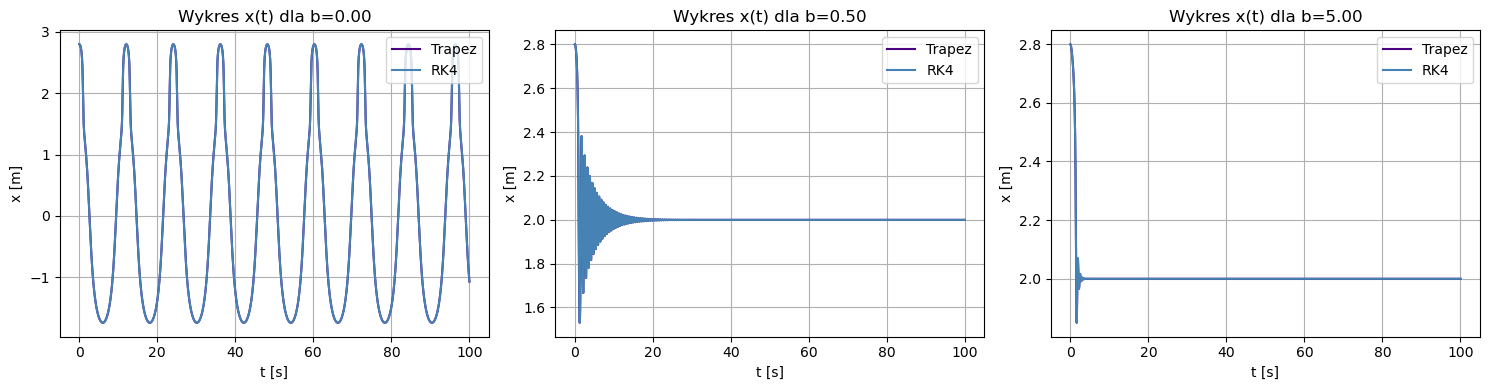

In [243]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

keys = [("Trapez b=0.00", "RK4 b=0.00"), ("Trapez b=0.50", "RK4 b=0.50"), ("Trapez b=5.00", "RK4 b=5.00")]

for i, (key_trapez, key_rk4) in enumerate(keys):
    t, dt, x, v, E, steps = results[key_trapez]
    t2, dt2, x2, v2, E2, steps2 = results_rk[key_rk4]

    axes[i].plot(t, x, label="Trapez", color="indigo")
    axes[i].plot(t2, x2, label="RK4", color="steelblue")
    axes[i].set_title(f"Wykres x(t) dla {key_trapez.split()[1]}")
    axes[i].set_xlabel("t [s]")
    axes[i].set_ylabel("x [m]")
    axes[i].grid(True)
    axes[i].legend(loc="upper right")

plt.tight_layout()
plt.show()


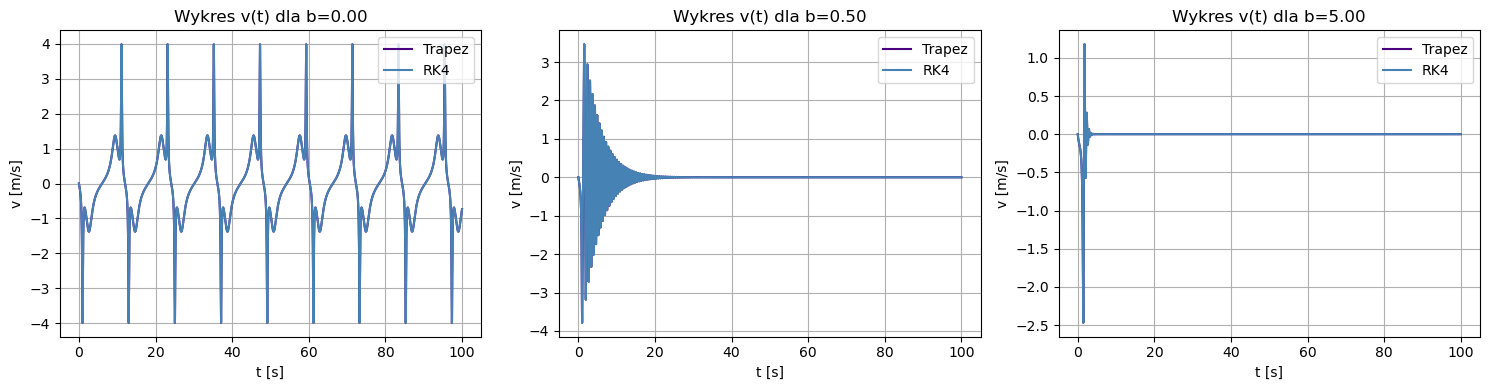

In [244]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (key_trapez, key_rk4) in enumerate(keys):
    t, dt, x, v, E, steps = results[key_trapez]
    t2, dt2, x2, v2, E2, steps2 = results_rk[key_rk4]

    axes[i].plot(t, v, label="Trapez", color="indigo")
    axes[i].plot(t2, v2, label="RK4", color="steelblue")
    axes[i].set_title(f"Wykres v(t) dla {key_trapez.split()[1]}")
    axes[i].set_xlabel("t [s]")
    axes[i].set_ylabel("v [m/s]")
    axes[i].grid(True)
    axes[i].legend(loc="upper right")

plt.tight_layout()
plt.show()

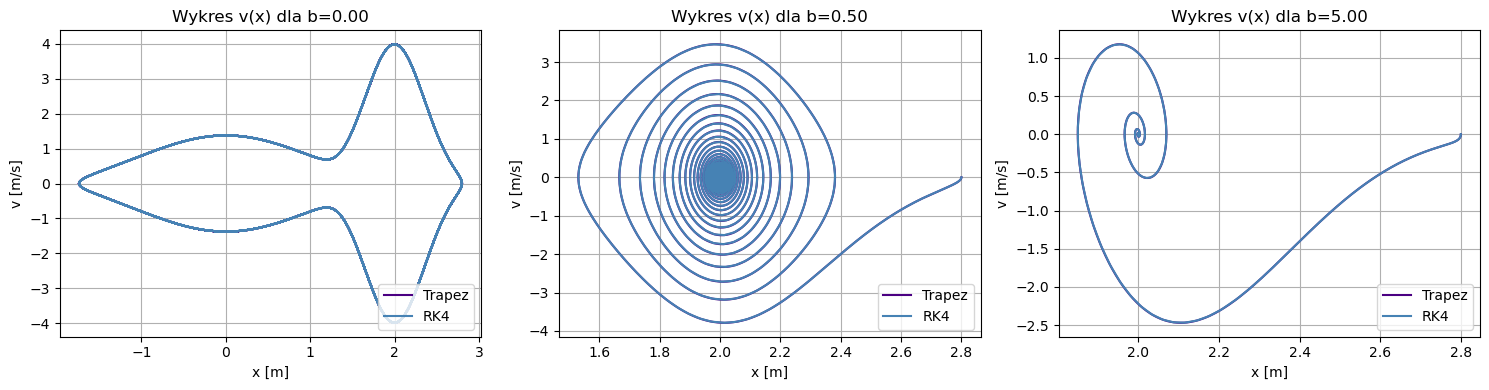

In [248]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (key_trapez, key_rk4) in enumerate(keys):
    t, dt, x, v, E, steps = results[key_trapez]
    t2, dt2, x2, v2, E2, steps2 = results_rk[key_rk4]

    axes[i].plot(x, v, label="Trapez", color="indigo")
    axes[i].plot(x2, v2, label="RK4", color="steelblue")
    axes[i].set_title(f"Wykres v(x) dla {key_trapez.split()[1]}")
    axes[i].set_xlabel("x [m]")
    axes[i].set_ylabel("v [m/s]")
    axes[i].grid(True)
    axes[i].legend(loc="lower right")

plt.tight_layout()
plt.show()

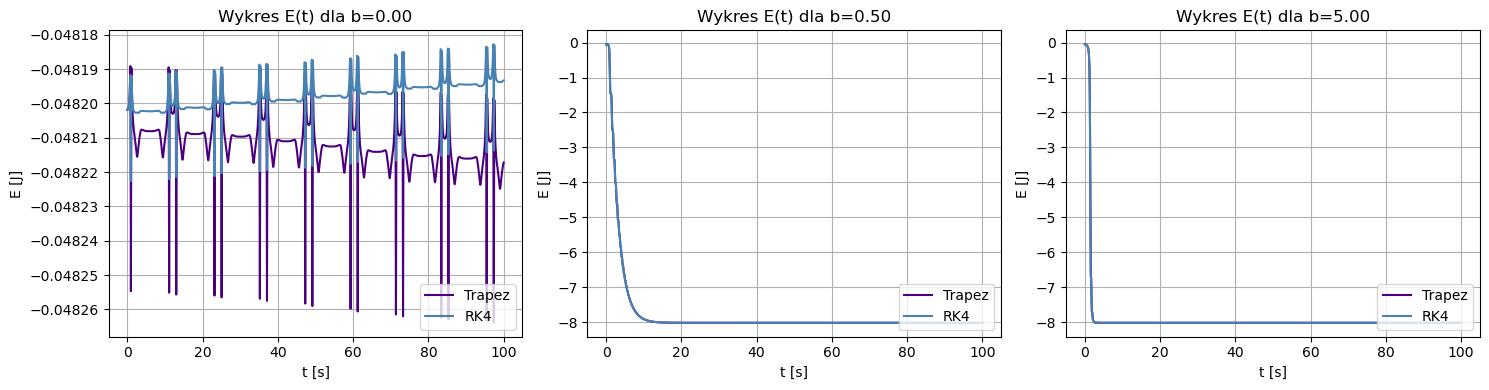

In [247]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (key_trapez, key_rk4) in enumerate(keys):
    t, dt, x, v, E, steps = results[key_trapez]
    t2, dt2, x2, v2, E2, steps2 = results_rk[key_rk4]

    axes[i].plot(t, E, label="Trapez", color="indigo")
    axes[i].plot(t2, E2, label="RK4", color="steelblue")
    axes[i].set_title(f"Wykres E(t) dla {key_trapez.split()[1]}")
    axes[i].set_xlabel("t [s]")
    axes[i].set_ylabel("E [J]")
    axes[i].grid(True)
    axes[i].legend(loc="lower right")

plt.tight_layout()
plt.show()